# Interpretable ML model using SHAP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
shap.initjs()

In [2]:
# Set the font family to Arial
print(plt.rcParams["font.family"])
plt.rcParams["font.sans-serif"] = ["Arial"] + plt.rcParams["font.sans-serif"]

['sans-serif']


In [3]:
# Load the model artifact
artifact = joblib.load("../data_processed/rsf_bundle.joblib")
artifact

{'model': RandomSurvivalForest(min_samples_leaf=30, min_samples_split=2, n_estimators=200,
                      random_state=2026),
 'cohort_scalers': {'LLU': StandardScaler(), 'UAB': StandardScaler()},
 'selected_features': ['il10', 'tnfalpha', 'ss'],
 'X_train':          il10  tnfalpha        ss
 37  -0.054554 -0.456563  0.680232
 100 -0.031440  0.138915  1.375923
 145 -0.417580 -0.768502  0.376605
 174 -0.440358 -0.460468  1.139472
 10  -0.433819 -0.803409  0.680232
 ..        ...       ...       ...
 79  -0.327063  0.316762  0.680232
 53   5.010077 -0.866230  0.680232
 108 -0.439215  1.391808  2.071615
 107 -0.327063  2.809276  1.375923
 0   -0.463858  0.016811 -1.406843
 
 [169 rows x 3 columns],
 'X_test':          il10  tnfalpha        ss
 91  -0.487871  0.145109 -0.015460
 176  1.397728 -0.128952  1.139472
 134 -0.246910  0.473302  1.902339
 63   0.429938  0.215009  0.680232
 21  -0.470513 -0.364542  1.375923
 15  -0.345950  0.471604  0.680232
 150 -0.519586 -0.983988  1.13947

In [4]:
# Extract the model and data from the artifact
rsf = artifact["model"]
X_train = artifact["X_train"]
X_test = artifact["X_test"]
y_train = artifact["y_train"]
y_test = artifact["y_test"]

In [5]:
rsf

RandomSurvivalForest(min_samples_leaf=30, min_samples_split=2, n_estimators=200,
                     random_state=2026)

In [6]:
# Specify the SHAP explainer for the Random Survival Forest model
explainer = shap.Explainer(rsf.predict, X_train)
shap_values = explainer(X_test)

Background dataset has 169 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=169 when initializing the masker.


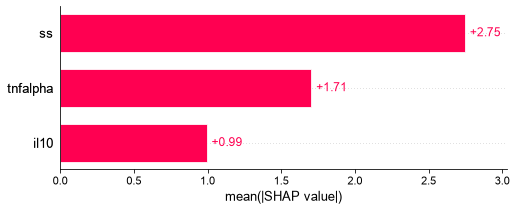

In [39]:
shap.plots.bar(shap_values)

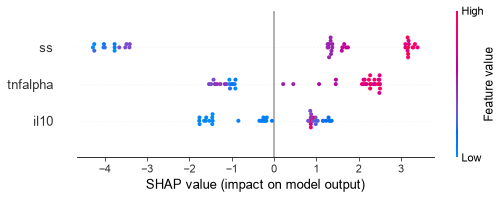

In [40]:
shap.plots.beeswarm(shap_values)

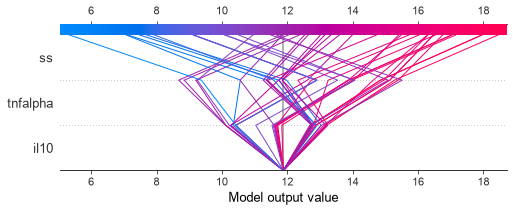

In [41]:
shap.decision_plot(
    base_value=shap_values.base_values[0],
    shap_values=shap_values.values,
    features=X_test,
    feature_names=X_test.columns.tolist()
)

In [ ]:
# shap.plots.waterfall(shap_values[0])

In [ ]:
# shap.plots.force(shap_values[0])

## Explainable predicted 2-year survival probability

In [6]:
# Define 2-years time point in days
t0 = 2 * 365.24

# Define a function to predict survival probability at 2 years
def predict_surv_2yr(X):
    surv_funcs = rsf.predict_survival_function(X)
    return np.array([fn(t0) for fn in surv_funcs])

# Explainer object for interpreting the survival probability at 2 years
explainer = shap.Explainer(predict_surv_2yr, X_train)
shap_values = explainer(X_test)

Background dataset has 169 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=169 when initializing the masker.


In [8]:
def plot_shap(
    plot_fn,
    plot_args=None,
    plot_kwargs=None,
    figsize=(10.5, 10),
    title=None,
    title_fontsize=8,
    label_fontsize=8,
    tick_fontsize=8,
    xlabel_fontsize=None,
    ylabel_fontsize=None,
    save_path=None,
    dpi=300,
    facecolor="white",
):
    """
    Reusable wrapper for shap plotting functions (bar, beeswarm, waterfall,
    scatter, etc.) with consistent sizing, fonts, backgrounds, and saving.

    Parameters
    ----------
    plot_fn : callable
        The shap plotting function itself, e.g. shap.plots.bar,
        shap.plots.beeswarm, shap.plots.waterfall.
    plot_args : list, optional
        Positional args to pass to plot_fn (e.g. [shap_values]).
    plot_kwargs : dict, optional
        Keyword args to pass to plot_fn (e.g. {"max_display": 10}).
    figsize : tuple(float, float)
        Width, height in inches.
    title : str, optional
        Plot title. If None, no title is set.
    title_fontsize, label_fontsize, tick_fontsize : int
        Font sizes for title, bar-end/text labels, and tick labels.
    xlabel_fontsize, ylabel_fontsize : int, optional
        Override font size for x/y axis labels specifically.
        Defaults to tick_fontsize if not given.
    save_path : str, optional
        If given, saves the figure to this path.
    dpi : int
        Resolution for saved figure.
    facecolor : str
        Background color applied to both figure and axes.

    Returns
    -------
    fig, ax : the matplotlib Figure and Axes objects, for further customization.
    """
    plot_args = plot_args or []
    plot_kwargs = plot_kwargs or {}

    # show=False so shap doesn't render/close the figure before we can edit it
    plot_fn(*plot_args, **plot_kwargs, show=False)

    fig = plt.gcf()
    ax = plt.gca()

    # --- sizing ---
    fig.set_size_inches(figsize[0], figsize[1])

    # --- fonts ---
    for text in ax.texts:  # bar-end values, force labels, etc.
        text.set_fontsize(label_fontsize)

    ax.tick_params(axis="both", labelsize=tick_fontsize, color="black")

    if ax.get_xlabel():
        ax.set_xlabel(ax.get_xlabel(), fontsize=xlabel_fontsize, color="black")
    if ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel(), fontsize=ylabel_fontsize, color="black")

    if title:
        ax.set_title(title, fontsize=title_fontsize)

    # --- backgrounds ---
    fig.patch.set_facecolor(facecolor)
    fig.patch.set_alpha(1)
    ax.patch.set_facecolor(facecolor)
    ax.patch.set_alpha(1)

    fig.tight_layout()
    plt.show()

    # --- saving ---
    if save_path:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor=fig.get_facecolor(),
            transparent=False,
        )

    return fig, ax

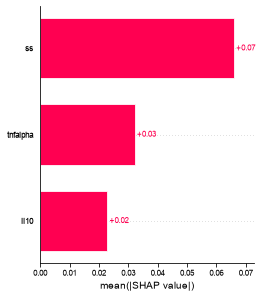

(<Figure size 270x306 with 1 Axes>, <Axes: xlabel='mean(|SHAP value|)'>)

In [10]:
# Global importance of each feature is taken to be the mean absolute value for that feature over all the given samples.
plot_shap(
    plot_fn=shap.plots.bar,
    plot_args=[shap_values],
    figsize=(3.75, 4.25),
    title="",
    label_fontsize=8,
    tick_fontsize=8,
    save_path="../figures/shap_global_feature_importance_ranking.pdf",
    dpi=300,
    facecolor="white",
)

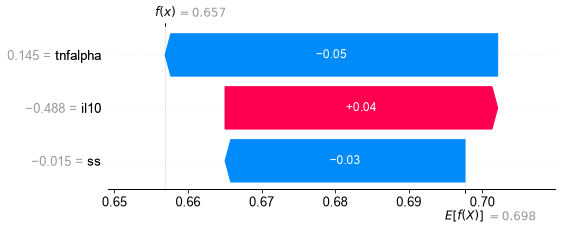

In [9]:
shap.plots.waterfall(shap_values[0])

In [10]:
shap.plots.force(shap_values[0])

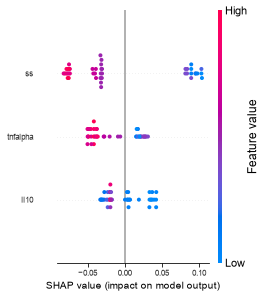

(<Figure size 270x306 with 2 Axes>,
 <Axes: xlabel='SHAP value (impact on model output)'>)

In [19]:
# SHAP: distribution of feature effects
plot_shap(
    plot_fn=shap.plots.beeswarm,
    plot_args=[shap_values],
    figsize=(3.75, 4.25),
    title="",
    title_fontsize=8,
    label_fontsize=8,
    tick_fontsize=8,
    save_path="../figures/shap_feature_effect_distribution.pdf",
    dpi=300,
    facecolor="white",
)

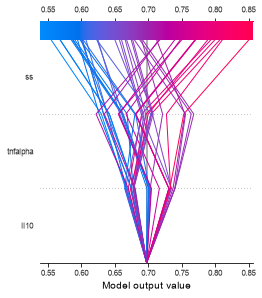

(<Figure size 270x306 with 1 Axes>, <Axes: xlabel='Model output value'>)

In [18]:
plot_shap(
    plot_fn=shap.decision_plot,
    plot_kwargs=dict(
        base_value=shap_values.base_values[0],
        shap_values=shap_values.values,
        features=X_test,
        feature_names=X_test.columns.tolist(),
    ),
    figsize=(3.75, 4.25),
    title="",
    title_fontsize=8,
    label_fontsize=8,
    tick_fontsize=8,
    save_path="../figures/shap_decision_plot.pdf",
    dpi=300,
    facecolor="white",
)

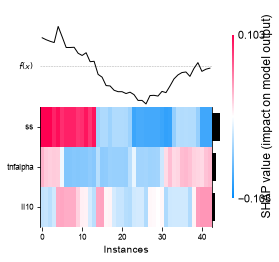

(<Figure size 270x270 with 2 Axes>, <Axes: xlabel='Instances'>)

In [21]:
plot_shap(
    plot_fn=shap.plots.heatmap,
    plot_kwargs=dict(
        shap_values=shap_values,
        # instance_order=shap_values.sum(1)
    ),
    figsize=(3.75, 3.75),
    title="",
    title_fontsize=8,
    label_fontsize=8,
    tick_fontsize=8,
    save_path="../figures/shap_heatmap_plot.pdf",
    dpi=300,
    facecolor="white",
)

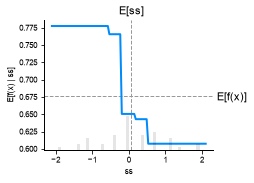

In [23]:
fig, ax = plt.subplots(figsize=( 9.5 / 2.54, 7 / 2.54))

shap.partial_dependence_plot(
    "ss",
    predict_surv_2yr,
    X_test,
    model_expected_value=True,
    feature_expected_value=True,
    ice=False,
    ax=ax,
    show=False,
)

fig.tight_layout()
ax.set_xlabel("ss", fontsize=8)
ax.yaxis.label.set_size(8)
ax.tick_params(axis="both", which="major", labelsize=8)
fig.savefig(
    "../figures/shap_partial_dependence_ss.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

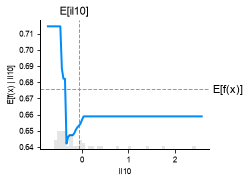

In [ ]:
fig, ax = plt.subplots(figsize=( 9.5 / 2.54, 7 / 2.54))

shap.partial_dependence_plot(
    "il10",
    predict_surv_2yr,
    X_test,
    model_expected_value=True,
    feature_expected_value=True,
    ice=False,
    ax=ax,
    show=False,
)

fig.tight_layout()
ax.set_xlabel("il10", fontsize=8)
ax.yaxis.label.set_size(8)
ax.tick_params(axis="both", which="major", labelsize=8)
fig.savefig(
    "../figures/shap_partial_dependence_il10.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

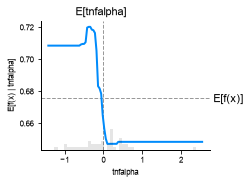

In [25]:
# shap.partial_dependence_plot(
#     "tnfalpha",
#     predict_surv_2yr,
#     X_test,
#     model_expected_value=True,
#     feature_expected_value=True,
#     ice=False,
# )

fig, ax = plt.subplots(figsize=( 9.5 / 2.54, 7 / 2.54))

shap.partial_dependence_plot(
    "tnfalpha",
    predict_surv_2yr,
    X_test,
    model_expected_value=True,
    feature_expected_value=True,
    ice=False,
    ax=ax,
    show=False,
)

fig.tight_layout()
ax.set_xlabel("tnfalpha", fontsize=8)
ax.yaxis.label.set_size(8)
ax.tick_params(axis="both", which="major", labelsize=8)
fig.savefig(
    "../figures/shap_partial_dependence_tnfalpha.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()